<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/Insurance_Charges_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Insurance Charges Prediction:**

# **Project Overview:**
This project focuses on predicting medical insurance charges using a Decision Tree Regressor. It involves comprehensive data analysis, preprocessing, model training, and hyperparameter tuning to build an effective predictive model.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Feature Importance
* Final Output
* Conclusion

### **Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

### **Dataset load:**

In [ ]:
df = pd.read_csv('/content/insurance.csv')

### **Dataset Overview:**

In [ ]:
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
display(df.tail())

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (1338, 7)


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
display(df.describe())

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
duplicates = df.duplicated().sum()
display(pd.DataFrame({'Duplicate Rows': [duplicates]}, index=['Duplicates']))

,Duplicate Rows
Duplicates,1


### **Data Cleaning:**

In [ ]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"Number of duplicate rows removed: {duplicates_removed}")
print(f"New dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows removed: 1
New dataset shape after removing duplicates: (1337, 7)


In [ ]:
df = df.astype({
    'sex': 'category',
    'smoker': 'category',
    'region': 'category'
})

In [ ]:
df.dtypes

,0
age,int64
sex,category
bmi,float64
children,int64
smoker,category
region,category
charges,float64


### **Outlier Section:**

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
outliers_count = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(col_outliers)

outliers_df = pd.DataFrame(outliers_count.items(), columns=['Column', 'Outliers Count'])
display(outliers_df)

,Column,Outliers Count
0,age,0
1,bmi,9
2,children,0
3,charges,139


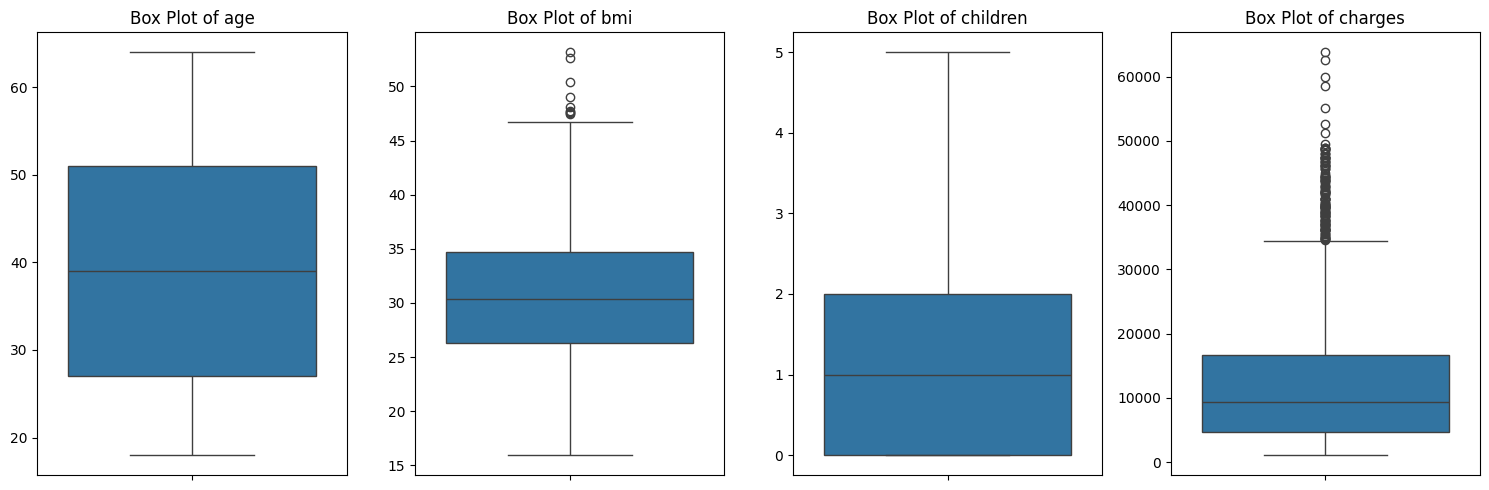

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Box plots show feature distributions and outliers before handling.

In [ ]:
outlier_columns_to_handle = ['bmi', 'charges']

for col in outlier_columns_to_handle:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

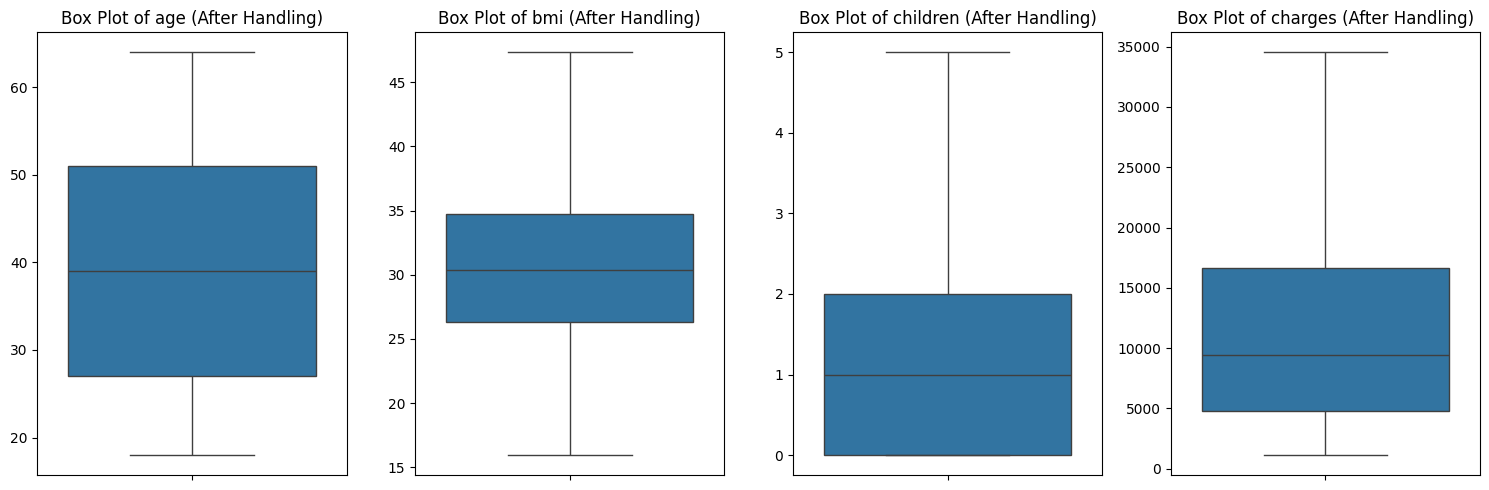

In [ ]:
numerical_cols_after_handling = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_after_handling):
    plt.subplot(1, len(numerical_cols_after_handling), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col} (After Handling)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Box plots show feature distributions after outlier capping.

### **Exploratory Data Analysis:**

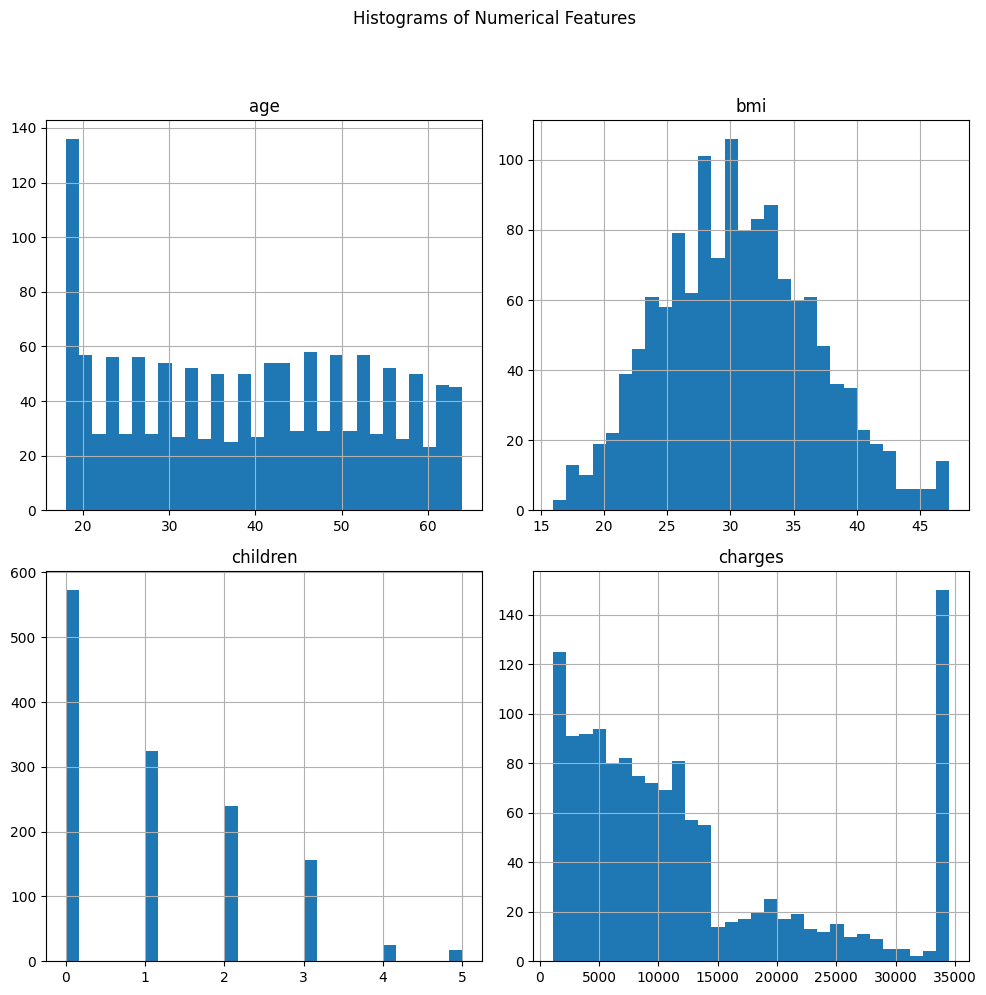

In [ ]:
numerical_cols_for_hist = df.select_dtypes(include=np.number).columns

df[numerical_cols_for_hist].hist(figsize=(10 , 10), bins=30)
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Histograms display the distribution of numerical features.

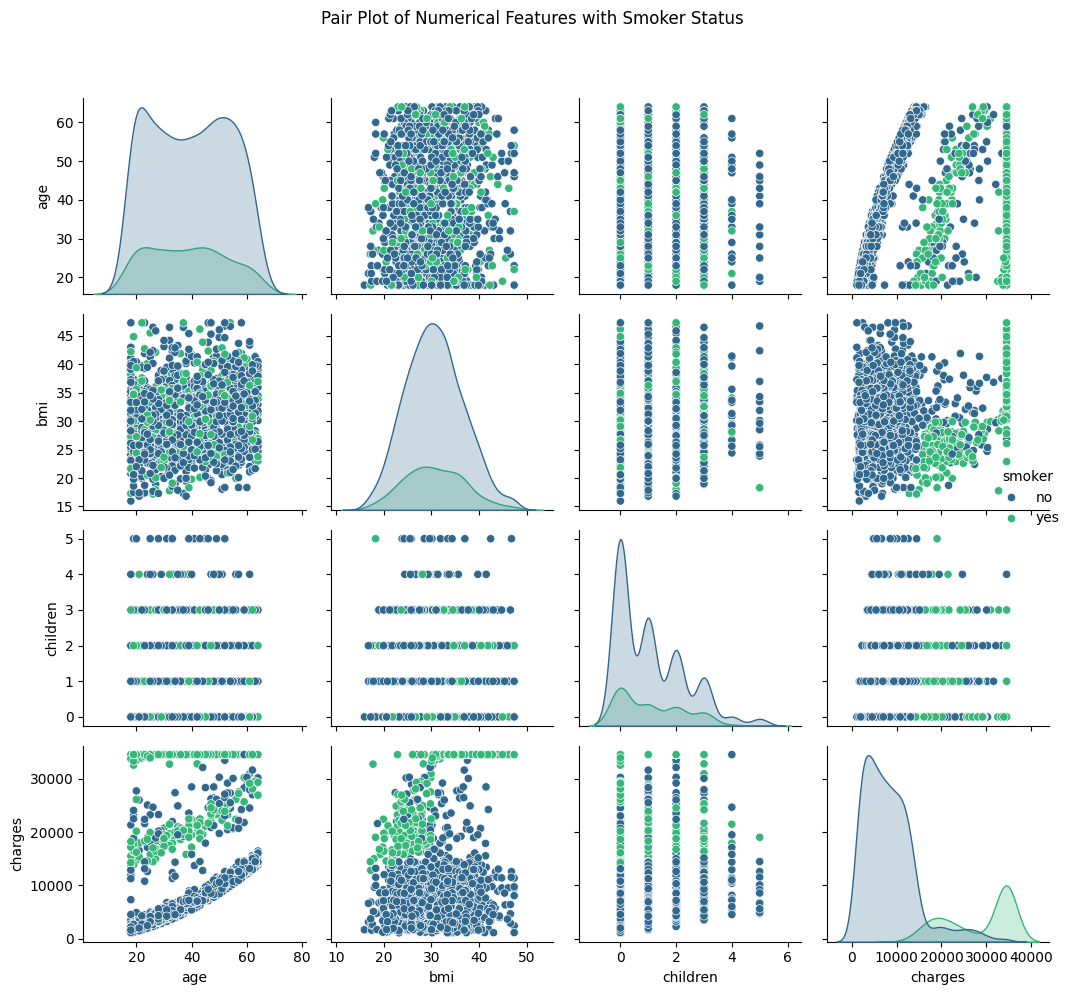

In [ ]:
sns.pairplot(df, hue='smoker', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features with Smoker Status', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Pair plot visualizes relationships between features by smoker status.

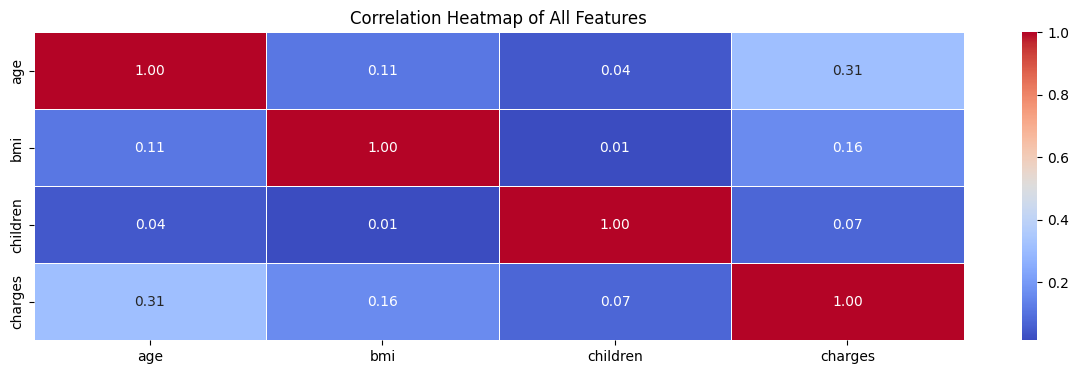

In [ ]:
plt.figure(figsize=(15 , 4))
sns.heatmap(df[numerical_cols_for_hist].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

Heatmap shows the correlation coefficients between numerical features.

### **Feature Engineering:**

In [ ]:
le = LabelEncoder()

categorical_cols_to_encode = ['sex', 'smoker', 'region']

for col in categorical_cols_to_encode:
    df[col] = le.fit_transform(df[col])

In [ ]:
print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
print("Data types after Label Encoding:")
display(df.dtypes)

Data types after Label Encoding:


,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region,int64
charges,float64


### **Data Preprocessing:**

In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (1337, 6)
Shape of y (target): (1337,)


### **Train-Test Split:**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1069, 6)
X_test shape: (268, 6)
y_train shape: (1069,)
y_test shape: (268,)


### **Feature Scaling:**

In [ ]:
scaler = StandardScaler()

numerical_features_for_scaling = ['age', 'bmi', 'children']

X_train[numerical_features_for_scaling] = scaler.fit_transform(X_train[numerical_features_for_scaling])

X_test[numerical_features_for_scaling] = scaler.transform(X_test[numerical_features_for_scaling])

### **Model Training:**

In [ ]:
dt_regressor = DecisionTreeRegressor(random_state=42)

In [ ]:
dt_regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_train_pred = dt_regressor.predict(X_train)

y_test_pred = dt_regressor.predict(X_test)

### **Model Evaluation:**

In [ ]:
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Training R2 Score: {r2_train:.4f}")
print(f"Training MAE: {mae_train:.2f}")
print(f"\nTest R2 Score: {r2_test:.4f}")
print(f"Test MAE: {mae_test:.2f}")

Training R2 Score: 1.0000
Training MAE: 0.00

Test R2 Score: 0.7163
Test MAE: 2419.92


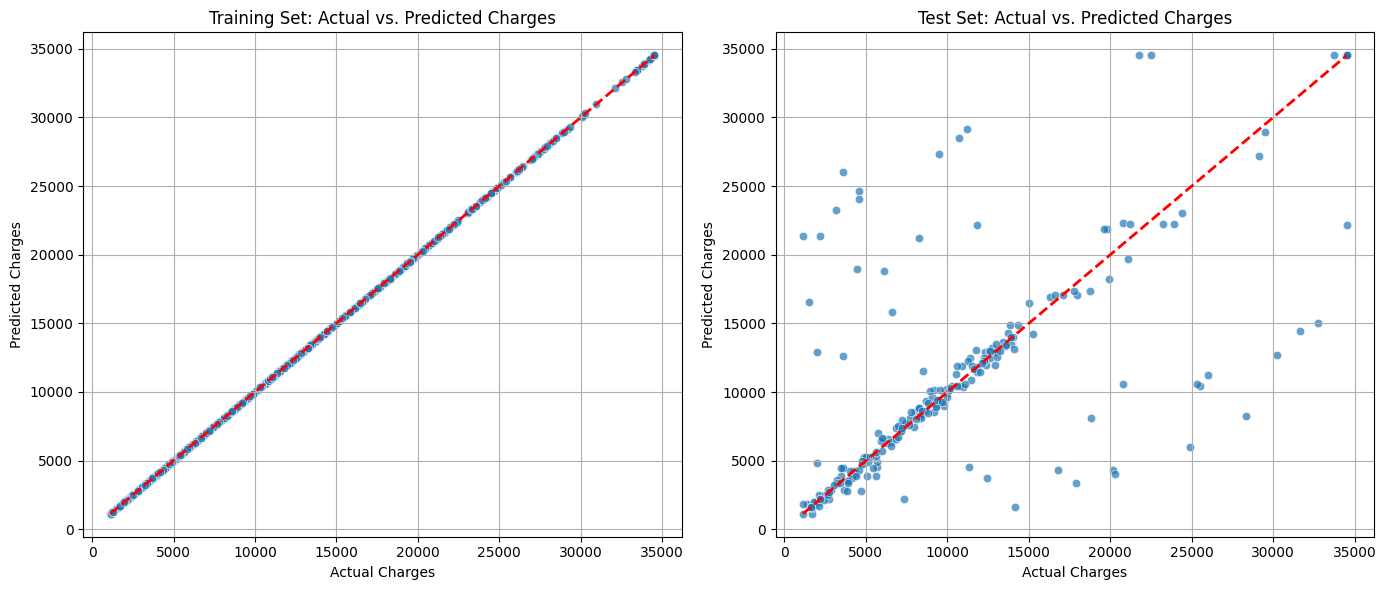

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.7)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title('Training Set: Actual vs. Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Test Set: Actual vs. Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True)

plt.tight_layout()
plt.show()

Scatter plots compare actual vs. predicted charges for the untuned model.

### **Train vs Test Score Check:**


In [ ]:
print(f"Difference in R2 Score (Train - Test): {r2_train - r2_test:.4f}")
print(f"Difference in MAE (Train - Test): {mae_train - mae_test:.2f}")

Difference in R2 Score (Train - Test): 0.2837
Difference in MAE (Train - Test): -2419.92


### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8, 16]
}

grid_search = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1,
                           verbose=1)

In [ ]:
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best cross-validation R2 score: {best_score:.4f}")

dt_regressor_tuned = DecisionTreeRegressor(random_state=42, **best_params)
dt_regressor_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters found: {'max_depth': 5, 'min_samples_leaf': 16}
Best cross-validation R2 score: 0.7863


DecisionTreeRegressor(max_depth=5, min_samples_leaf=16, random_state=42)

In [ ]:
y_train_pred_tuned = dt_regressor_tuned.predict(X_train)
y_test_pred_tuned = dt_regressor_tuned.predict(X_test)

r2_train_tuned = r2_score(y_train, y_train_pred_tuned)
mae_train_tuned = mean_absolute_error(y_train, y_train_pred_tuned)

r2_test_tuned = r2_score(y_test, y_test_pred_tuned)
mae_test_tuned = mean_absolute_error(y_test, y_test_pred_tuned)

print(f"Tuned Training R2 Score: {r2_train_tuned:.4f}")
print(f"Tuned Training MAE: {mae_train_tuned:.2f}")
print(f"\nTuned Test R2 Score: {r2_test_tuned:.4f}")
print(f"Tuned Test MAE: {mae_test_tuned:.2f}")

Tuned Training R2 Score: 0.8282
Tuned Training MAE: 2236.73

Tuned Test R2 Score: 0.8721
Tuned Test MAE: 2128.49


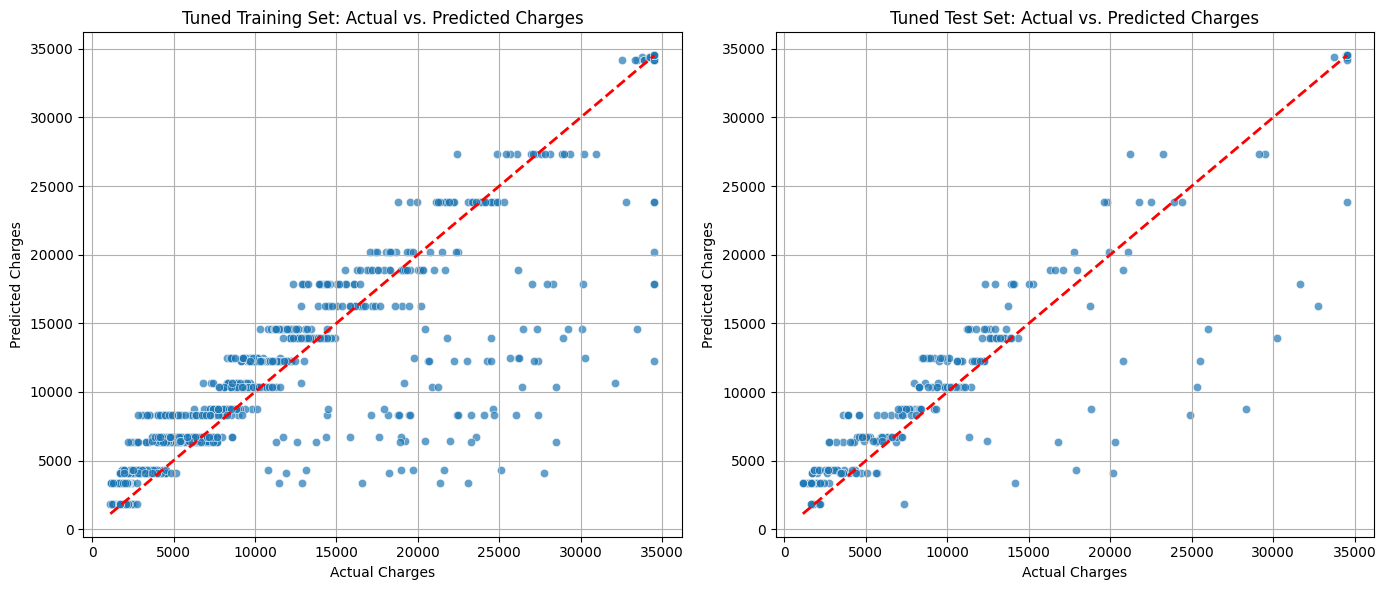

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_train_pred_tuned, alpha=0.7)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title('Tuned Training Set: Actual vs. Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_test_pred_tuned, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Tuned Test Set: Actual vs. Predicted Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid(True)

plt.tight_layout()
plt.show()

### **Cross-Validation:**

In [ ]:
cv_scores = cross_val_score(dt_regressor_tuned, X, y, cv=5, scoring='r2', n_jobs=-1)

print(f"Cross-validation R2 scores: {cv_scores}")
print(f"Mean CV R2 score: {cv_scores.mean():.4f}")

Cross-validation R2 scores: [0.83992239 0.71904011 0.86707172 0.80959444 0.84333205]
Mean CV R2 score: 0.8158


### **Pipeline (final packaging):**

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=42, **best_params))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=16,
                                       random_state=42))])

In [ ]:
y_test_pred_pipeline = pipeline.predict(X_test)

r2_test_pipeline = r2_score(y_test, y_test_pred_pipeline)
mae_test_pipeline = mean_absolute_error(y_test, y_test_pred_pipeline)

### **Final Output:**

In [ ]:
final_metrics_df = pd.DataFrame({
    'Metric': ['R2 Score', 'MAE'],
    'Value': [r2_test_pipeline, mae_test_pipeline]
})
display(final_metrics_df)

,Metric,Value
0,R2 Score,0.872096
1,MAE,2128.488670


# **Conclusion:**
- The dataset was cleaned, and categorical features were encoded.
- An initial Decision Tree model showed overfitting, which was addressed through hyperparameter tuning.
- The tuned model, integrated into a pipeline, achieved a good R2 score of 0.8721 and an MAE of 2128.49 on unseen test data, indicating strong predictive performance for insurance charges.